# $$\text{A deep neural network of energy absorbing structures}$$

This time we have additional interpolated- and extrapolated data. All the data is stored in 'Data Exercise 2'. The three first columns represent the input and the two last columns are the outputs.

#### $$\text{1 - Importing the necessary python modules}$$

# $$\text{A deep neural network of energy absorbing structures}$$

This time we have additional interpolated and extrapolated data. All the data is stored in `Data_Exercise_2`. The first three columns represent the input variables and the last two columns are the output variables.


#### $$\text{1 - Importing the necessary python modules}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

#### $$\text{GPU Acceleration with CUDA}$$

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#### $$\text{Loading the data}$$

In [3]:
data = np.loadtxt("Data_Exercise_2/data.txt", delimiter=",")

### $$\text{2 - Splitting the raw data}$$

In [4]:
def split_XY(data):
    X = data[:, :3]
    Y = data[:, 3:]
    return X, Y


X_raw, Y_raw = split_XY(data)

X_raw_train, X_raw_val, Y_raw_train, Y_raw_val = train_test_split(
    X_raw,
    Y_raw,
    test_size=0.2,
    random_state=1,
    shuffle=True
)

### $$\text{3 - Scaling the data}$$

In [5]:
def to_tensor(array):
    return torch.tensor(array, dtype=torch.float32).to(device)


X_scaler = MinMaxScaler()
Y_scaler = MinMaxScaler()

trainX_scaled = X_scaler.fit_transform(X_raw_train)
valX_scaled = X_scaler.transform(X_raw_val)

trainY_scaled = Y_scaler.fit_transform(Y_raw_train)
valY_scaled = Y_scaler.transform(Y_raw_val)

trainX = to_tensor(trainX_scaled)
valX = to_tensor(valX_scaled)

trainY = to_tensor(trainY_scaled)
valY = to_tensor(valY_scaled)

### $$\text{4 - Creating a two layer A.N.N.}$$

In [6]:
class ANN(nn.Module):
    def __init__(self, numHidden=10):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(3, numHidden),
            nn.ReLU(),
            nn.Linear(numHidden, numHidden),
            nn.ReLU(),
            nn.Linear(numHidden, 2)
        )

    def forward(self, x):
        return self.model(x)

### $$\text{5 - Training for 100 epochs using Adam optimizer}$$

In [7]:
def train_model(model, loader, valX, valY, lossFunction, optimizer, epochs):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()

        epoch_loss = 0.0
        samples = 0

        for X_batch, Y_batch in loader:
            prediction = model(X_batch)
            loss = lossFunction(prediction, Y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_size = X_batch.size(0)
            epoch_loss += loss.item() * batch_size
            samples += batch_size

        train_loss = epoch_loss / samples
        train_losses.append(train_loss)

        model.eval()
        with torch.no_grad():
            val_prediction = model(valX)
            val_loss = lossFunction(val_prediction, valY).item()

        val_losses.append(val_loss)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Training Loss: {train_loss:.6f} | "
            f"Validation Loss: {val_loss:.6f}"
        )

    return train_losses, val_losses

In [8]:
dataset = TensorDataset(trainX, trainY)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

model = ANN(numHidden=10).to(device)

lossFunction = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100

train_losses, val_losses = train_model(
    model,
    loader,
    valX,
    valY,
    lossFunction,
    optimizer,
    epochs
)

Epoch 1/100 | Training Loss: 0.172692 | Validation Loss: 0.120976
Epoch 2/100 | Training Loss: 0.088268 | Validation Loss: 0.057716
Epoch 3/100 | Training Loss: 0.040809 | Validation Loss: 0.027381
Epoch 4/100 | Training Loss: 0.024508 | Validation Loss: 0.020766
Epoch 5/100 | Training Loss: 0.021694 | Validation Loss: 0.019198
Epoch 6/100 | Training Loss: 0.020148 | Validation Loss: 0.017934
Epoch 7/100 | Training Loss: 0.018832 | Validation Loss: 0.016582
Epoch 8/100 | Training Loss: 0.017517 | Validation Loss: 0.015301
Epoch 9/100 | Training Loss: 0.016065 | Validation Loss: 0.013860
Epoch 10/100 | Training Loss: 0.014447 | Validation Loss: 0.012228
Epoch 11/100 | Training Loss: 0.012584 | Validation Loss: 0.010176
Epoch 12/100 | Training Loss: 0.010269 | Validation Loss: 0.008029
Epoch 13/100 | Training Loss: 0.008061 | Validation Loss: 0.005976
Epoch 14/100 | Training Loss: 0.006016 | Validation Loss: 0.004318
Epoch 15/100 | Training Loss: 0.004543 | Validation Loss: 0.003190
Epoc

### $$\text{6 - Visualization of training and validation loss}$$

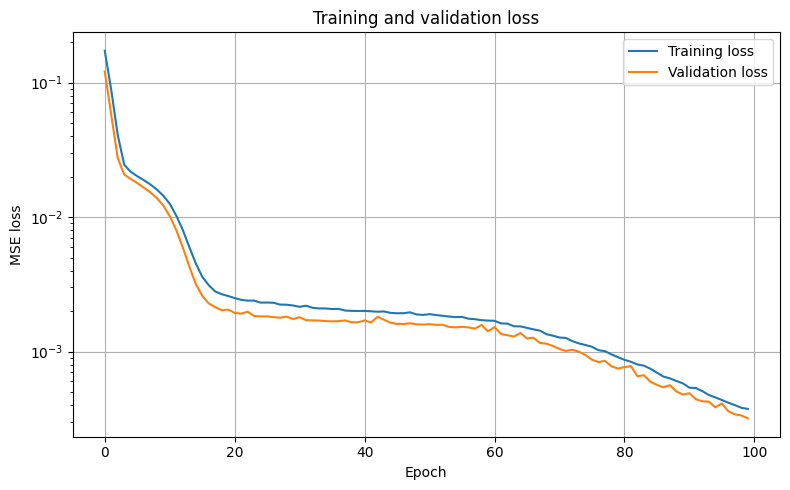

In [9]:
plt.figure(figsize=(8, 5))

plt.semilogy(train_losses, label="Training loss")
plt.semilogy(val_losses, label="Validation loss")

plt.title("Training and validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### $$\text{7 - Loading the extrapolated and interpolated data}$$

In [10]:
def scale_and_tensor(X_raw, Y_raw, X_scaler, Y_scaler):
    X_scaled = X_scaler.transform(X_raw)
    Y_scaled = Y_scaler.transform(Y_raw)

    X = to_tensor(X_scaled)
    Y = to_tensor(Y_scaled)

    return X, Y


interpolated_data = np.loadtxt("Data_Exercise_2/interpolated.txt", delimiter=",")
extrapolated_data = np.loadtxt("Data_Exercise_2/extrapolated.txt", delimiter=",")

X_raw_interp, Y_raw_interp = split_XY(interpolated_data)
X_raw_extra, Y_raw_extra = split_XY(extrapolated_data)

interpX, interpY = scale_and_tensor(X_raw_interp, Y_raw_interp, X_scaler, Y_scaler)
extraX, extraY = scale_and_tensor(X_raw_extra, Y_raw_extra, X_scaler, Y_scaler)

### $$\text{8 - Evaluating the ANN on interpolated and extrapolated data}$$

In [11]:
def evaluate_model(model, X, Y, Y_raw, Y_scaler, lossFunction):
    model.eval()

    with torch.no_grad():
        prediction_scaled = model(X)
        loss = lossFunction(prediction_scaled, Y).item()

    prediction_raw = Y_scaler.inverse_transform(
        prediction_scaled.cpu().numpy()
    )

    return prediction_raw, loss


interp_prediction_raw, interp_loss = evaluate_model(
    model,
    interpX,
    interpY,
    Y_raw_interp,
    Y_scaler,
    lossFunction
)

extra_prediction_raw, extra_loss = evaluate_model(
    model,
    extraX,
    extraY,
    Y_raw_extra,
    Y_scaler,
    lossFunction
)

print(f"Final training loss:       {train_losses[-1]:.6f}")
print(f"Final validation loss:     {val_losses[-1]:.6f}")
print(f"Interpolated data loss:    {interp_loss:.6f}")
print(f"Extrapolated data loss:    {extra_loss:.6f}")

Final training loss:       0.000374
Final validation loss:     0.000319
Interpolated data loss:    0.000253
Extrapolated data loss:    0.116814


### $$\text{9 - Inverse scaling of predictions}$$

The inverse scaling is performed inside `evaluate_model`, which returns predictions in the original output scale.


In [12]:
interpY_raw = Y_raw_interp
extraY_raw = Y_raw_extra

### $$\text{10 - Plotting interpolated and extrapolated results using subplots}$$

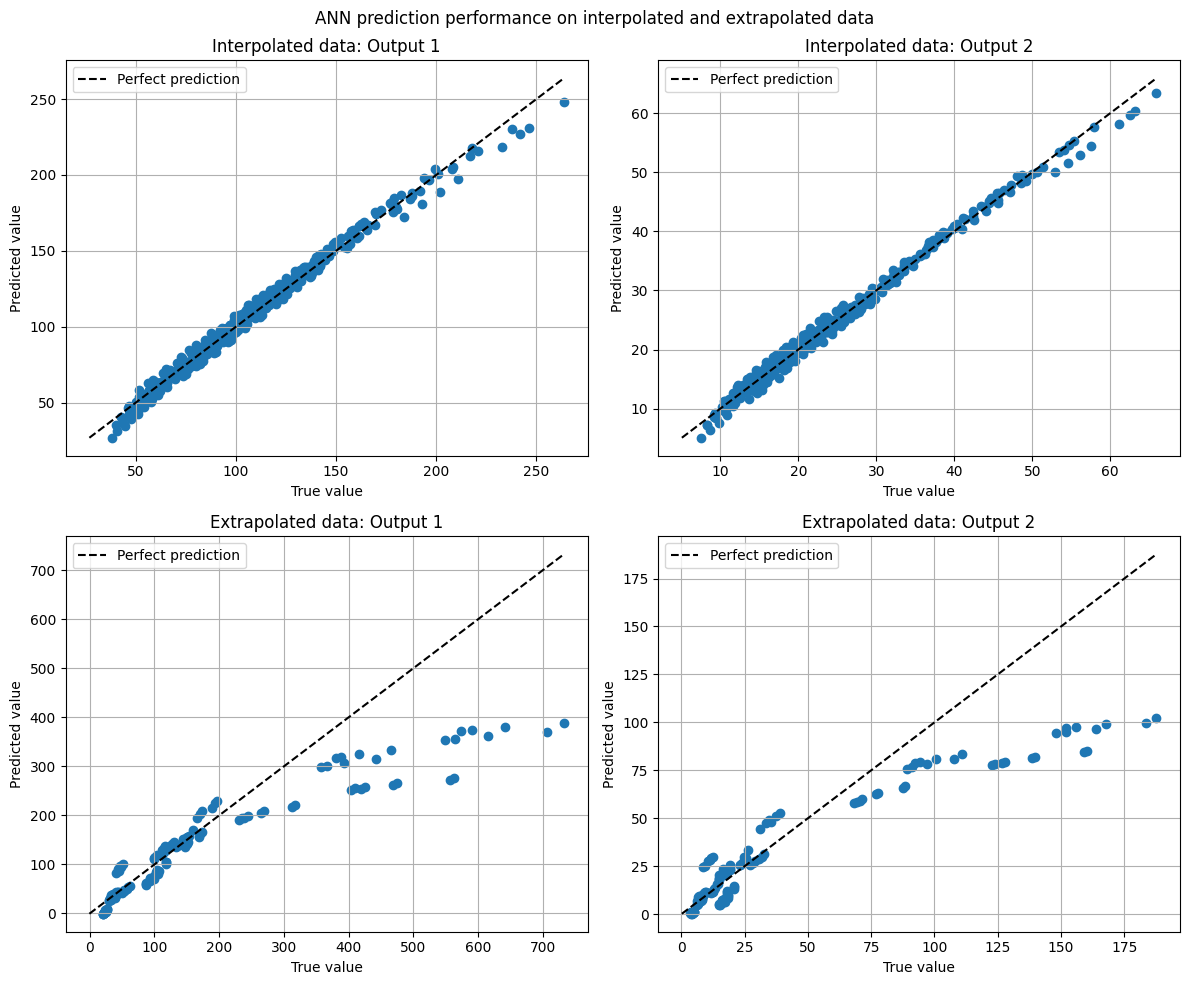

In [13]:
def plot_prediction(ax, true, predicted, title):
    ax.scatter(true, predicted)

    min_val = min(true.min(), predicted.min())
    max_val = max(true.max(), predicted.max())

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        "k--",
        label="Perfect prediction"
    )

    ax.set_title(title)
    ax.set_xlabel("True value")
    ax.set_ylabel("Predicted value")
    ax.legend()
    ax.grid()


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_prediction(
    axes[0, 0],
    interpY_raw[:, 0],
    interp_prediction_raw[:, 0],
    "Interpolated data: Output 1"
)

plot_prediction(
    axes[0, 1],
    interpY_raw[:, 1],
    interp_prediction_raw[:, 1],
    "Interpolated data: Output 2"
)

plot_prediction(
    axes[1, 0],
    extraY_raw[:, 0],
    extra_prediction_raw[:, 0],
    "Extrapolated data: Output 1"
)

plot_prediction(
    axes[1, 1],
    extraY_raw[:, 1],
    extra_prediction_raw[:, 1],
    "Extrapolated data: Output 2"
)

plt.suptitle("ANN prediction performance on interpolated and extrapolated data")
plt.tight_layout()
plt.show()

In [14]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn import preprocessing

#### $$\text{GPU Acceleration with CUDA}$$

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#### $$\text{Loading the data}$$

In [16]:
data = np.loadtxt("Data_Exercise_2/data.txt", delimiter=",")

### $$\text{2 - Splitting the raw data}$$

In [17]:
X_raw = data[:, 0:3]
Y_raw = data[:, 3:]

X_raw_train, X_raw_val, Y_raw_train, Y_raw_val = train_test_split(
    X_raw,
    Y_raw,
    test_size=0.2,
    random_state=1,
    shuffle=True
)

### $$\text{3 - Scaling the data}$$

In [18]:
X_scaler = preprocessing.MinMaxScaler()
Y_scaler = preprocessing.MinMaxScaler()

trainX_scaled = X_scaler.fit_transform(X_raw_train)
valX_scaled = X_scaler.transform(X_raw_val)

trainY_scaled = Y_scaler.fit_transform(Y_raw_train)
valY_scaled = Y_scaler.transform(Y_raw_val)

trainX = torch.tensor(trainX_scaled, dtype=torch.float32).to(device)
valX = torch.tensor(valX_scaled, dtype=torch.float32).to(device)

trainY = torch.tensor(trainY_scaled, dtype=torch.float32).to(device)
valY = torch.tensor(valY_scaled, dtype=torch.float32).to(device)

### $$\text{4 - Creating a two layer A.N.N.}$$

In [19]:
class ANN(nn.Module):
    def __init__(self, numHidden=10):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(3, numHidden),            # 3 inputs -> 10 hidden neurons
            nn.ReLU(),
            nn.Linear(numHidden, numHidden),    # 10 hidden neurons -> 10 hidden neurons
            nn.ReLU(),
            nn.Linear(numHidden, 2)             # 10 hidden neurons -> 2 outputs
        )

    def forward(self, x):
        return self.model(x)

### $$\text{5 - Training for 100 epochs using Adam optimizer}$$

In [20]:
dataset = TensorDataset(trainX, trainY)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

model = ANN(numHidden=10).to(device)

lossFunction = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()

    epoch_loss = 0.0
    samples = 0

    for X_batch, Y_batch in loader:
        prediction = model(X_batch)
        loss = lossFunction(prediction, Y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = X_batch.size(0)
        epoch_loss += loss.item() * batch_size
        samples += batch_size

    train_loss = epoch_loss / samples
    train_losses.append(train_loss)

    model.eval()
    with torch.no_grad():
        val_prediction = model(valX)
        val_loss = lossFunction(val_prediction, valY).item()

    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} |"
        f" Training Loss: {train_loss:.6f} |"
        f" Validation Loss: {val_loss:.6f}"
    )

Epoch 1/100 | Training Loss: 0.219701 | Validation Loss: 0.194113
Epoch 2/100 | Training Loss: 0.165488 | Validation Loss: 0.137326
Epoch 3/100 | Training Loss: 0.106017 | Validation Loss: 0.076399
Epoch 4/100 | Training Loss: 0.049583 | Validation Loss: 0.030110
Epoch 5/100 | Training Loss: 0.022940 | Validation Loss: 0.019319
Epoch 6/100 | Training Loss: 0.018775 | Validation Loss: 0.016730
Epoch 7/100 | Training Loss: 0.016199 | Validation Loss: 0.014522
Epoch 8/100 | Training Loss: 0.014011 | Validation Loss: 0.012375
Epoch 9/100 | Training Loss: 0.011998 | Validation Loss: 0.010306
Epoch 10/100 | Training Loss: 0.009905 | Validation Loss: 0.008118
Epoch 11/100 | Training Loss: 0.007979 | Validation Loss: 0.006420
Epoch 12/100 | Training Loss: 0.006360 | Validation Loss: 0.005021
Epoch 13/100 | Training Loss: 0.005139 | Validation Loss: 0.003971
Epoch 14/100 | Training Loss: 0.004282 | Validation Loss: 0.003280
Epoch 15/100 | Training Loss: 0.003668 | Validation Loss: 0.002859
Epoc

### $$\text{6 - Visualization of training and validation loss}$$

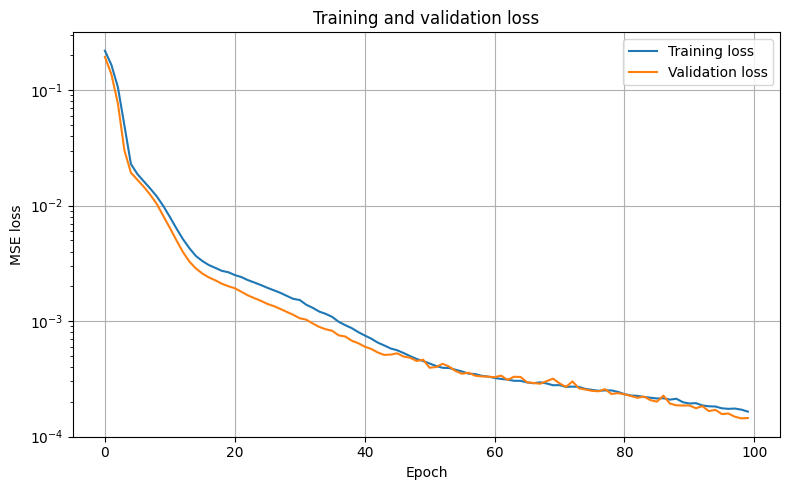

In [21]:
plt.figure(figsize=(8, 5))

plt.semilogy(train_losses, label="Training loss")
plt.semilogy(val_losses, label="Validation loss")

plt.title("Training and validation loss")

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()

plt.tight_layout()
plt.grid()
plt.show()

### $$\text{7 - Loading the extrapolated and interpolated data}$$

In [22]:
interpolated_data = np.loadtxt("Data_Exercise_2/interpolated.txt", delimiter=",")
extrapolated_data = np.loadtxt("Data_Exercise_2/extrapolated.txt", delimiter=",")

X_raw_interp = interpolated_data[:, 0:3]
Y_raw_interp = interpolated_data[:, 3:]

X_raw_extra = extrapolated_data[:, 0:3]
Y_raw_extra = extrapolated_data[:, 3:]

In [23]:
interpX_scaled = X_scaler.transform(X_raw_interp)
interpY_scaled = Y_scaler.transform(Y_raw_interp)

extraX_scaled = X_scaler.transform(X_raw_extra)
extraY_scaled = Y_scaler.transform(Y_raw_extra)

interpX = torch.tensor(interpX_scaled, dtype=torch.float32).to(device)
interpY = torch.tensor(interpY_scaled, dtype=torch.float32).to(device)

extraX = torch.tensor(extraX_scaled, dtype=torch.float32).to(device)
extraY = torch.tensor(extraY_scaled, dtype=torch.float32).to(device)

### $$\text{8 - Evaluating the ANN on interpolated and extrapolated data}$$


In [24]:
model.eval()

with torch.no_grad():
    interp_prediction_scaled = model(interpX)
    extra_prediction_scaled = model(extraX)

    interp_loss = lossFunction(interp_prediction_scaled, interpY).item()
    extra_loss = lossFunction(extra_prediction_scaled, extraY).item()

print(f"Interpolated data MSE loss: {interp_loss:.6f}")
print(f"Extrapolated data MSE loss: {extra_loss:.6f}")

Interpolated data MSE loss: 0.000112
Extrapolated data MSE loss: 0.094458


### $$\text{9 - Inverse scaling of predictions}$$

In [25]:
interp_prediction_raw = Y_scaler.inverse_transform(
    interp_prediction_scaled.cpu().numpy()
)

extra_prediction_raw = Y_scaler.inverse_transform(
    extra_prediction_scaled.cpu().numpy()
)

interpY_raw = Y_raw_interp
extraY_raw = Y_raw_extra

### $$\text{10 - Plotting interpolated and extrapolated results using subplots}$$

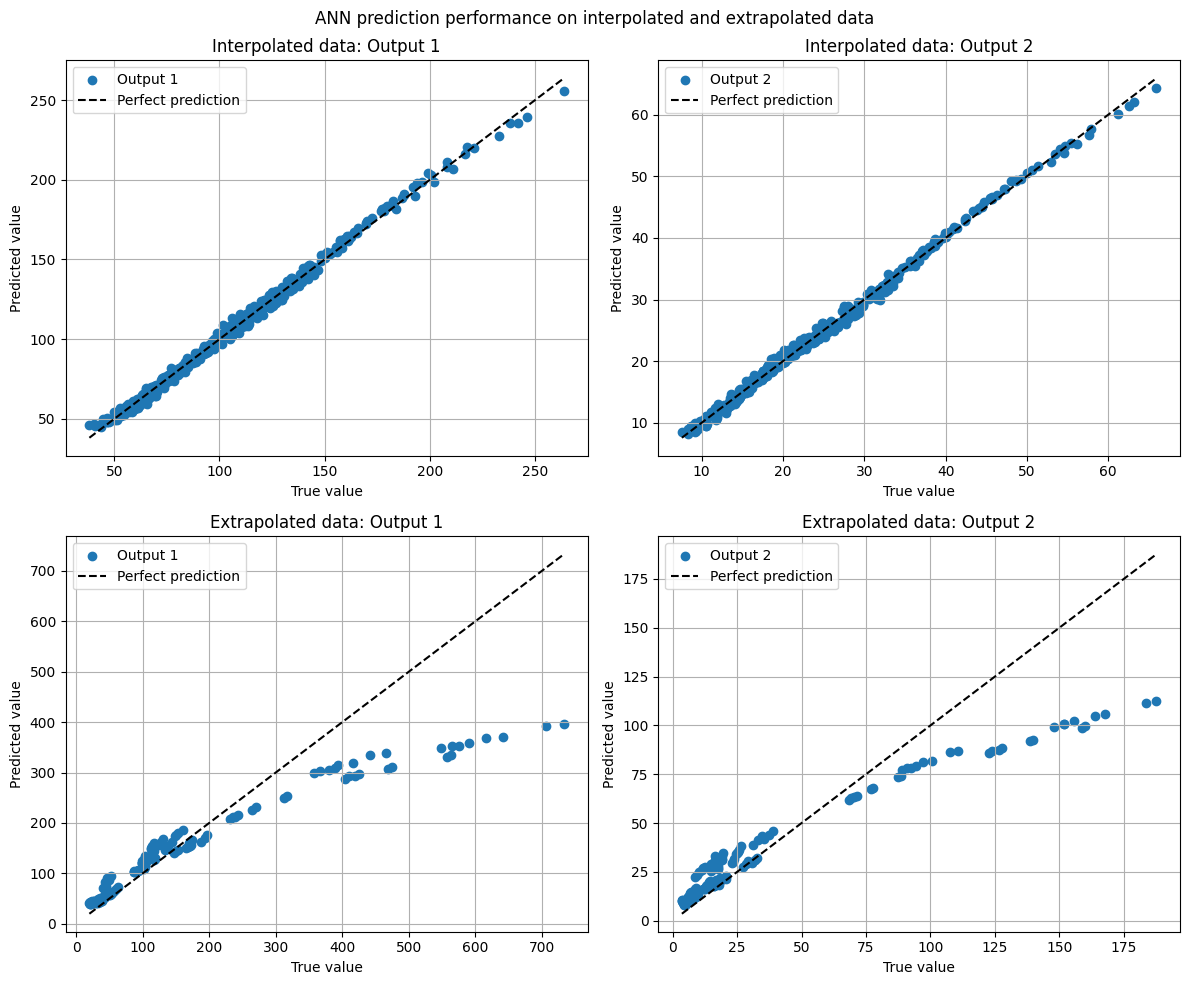

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Interpolated data - Output 1
axes[0, 0].scatter(interpY_raw[:, 0], interp_prediction_raw[:, 0], label="Output 1")
axes[0, 0].plot(
    [interpY_raw[:, 0].min(), interpY_raw[:, 0].max()],
    [interpY_raw[:, 0].min(), interpY_raw[:, 0].max()],
    "k--",
    label="Perfect prediction"
)
axes[0, 0].set_title("Interpolated data: Output 1")
axes[0, 0].set_xlabel("True value")
axes[0, 0].set_ylabel("Predicted value")
axes[0, 0].legend()
axes[0, 0].grid()

# Interpolated data - Output 2
axes[0, 1].scatter(interpY_raw[:, 1], interp_prediction_raw[:, 1], label="Output 2")
axes[0, 1].plot(
    [interpY_raw[:, 1].min(), interpY_raw[:, 1].max()],
    [interpY_raw[:, 1].min(), interpY_raw[:, 1].max()],
    "k--",
    label="Perfect prediction"
)
axes[0, 1].set_title("Interpolated data: Output 2")
axes[0, 1].set_xlabel("True value")
axes[0, 1].set_ylabel("Predicted value")
axes[0, 1].legend()
axes[0, 1].grid()

# Extrapolated data - Output 1
axes[1, 0].scatter(extraY_raw[:, 0], extra_prediction_raw[:, 0], label="Output 1")
axes[1, 0].plot(
    [extraY_raw[:, 0].min(), extraY_raw[:, 0].max()],
    [extraY_raw[:, 0].min(), extraY_raw[:, 0].max()],
    "k--",
    label="Perfect prediction"
)
axes[1, 0].set_title("Extrapolated data: Output 1")
axes[1, 0].set_xlabel("True value")
axes[1, 0].set_ylabel("Predicted value")
axes[1, 0].legend()
axes[1, 0].grid()

# Extrapolated data - Output 2
axes[1, 1].scatter(extraY_raw[:, 1], extra_prediction_raw[:, 1], label="Output 2")
axes[1, 1].plot(
    [extraY_raw[:, 1].min(), extraY_raw[:, 1].max()],
    [extraY_raw[:, 1].min(), extraY_raw[:, 1].max()],
    "k--",
    label="Perfect prediction"
)
axes[1, 1].set_title("Extrapolated data: Output 2")
axes[1, 1].set_xlabel("True value")
axes[1, 1].set_ylabel("Predicted value")
axes[1, 1].legend()
axes[1, 1].grid()

plt.suptitle("ANN prediction performance on interpolated and extrapolated data")
plt.tight_layout()
plt.show()